Saving github.csv to github (1).csv


<ipython-input-1-c8c98bb4c5fe>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pearson r', y='Feature', data=pearson_df.head(10), palette='coolwarm')


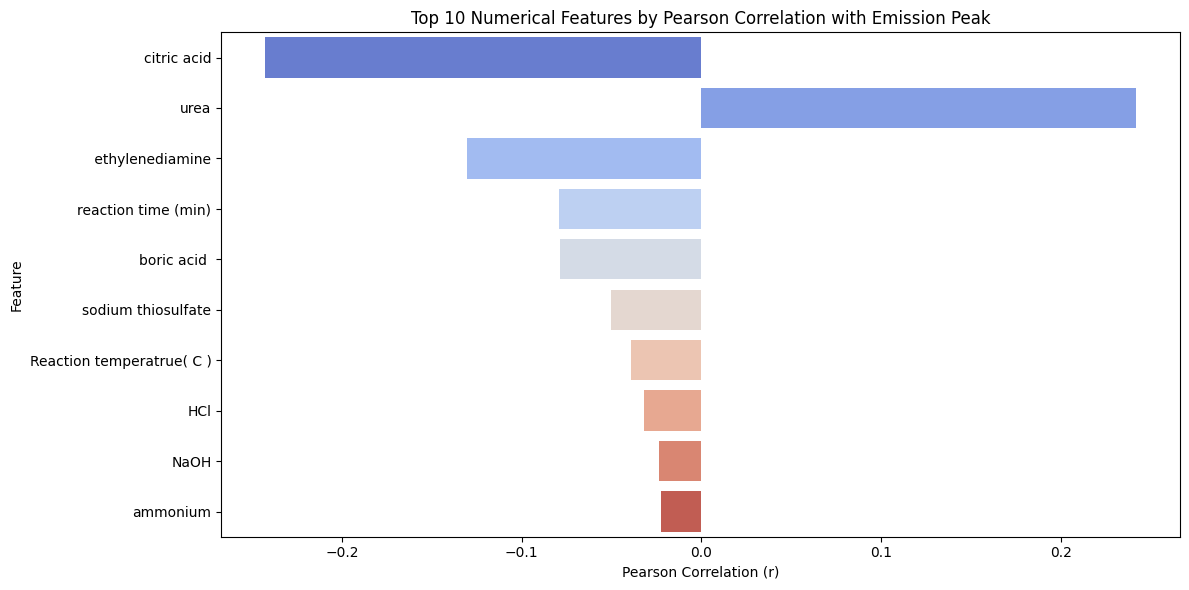

<ipython-input-1-c8c98bb4c5fe>:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-statistic', y='Feature', data=anova_df.head(10), palette='mako')


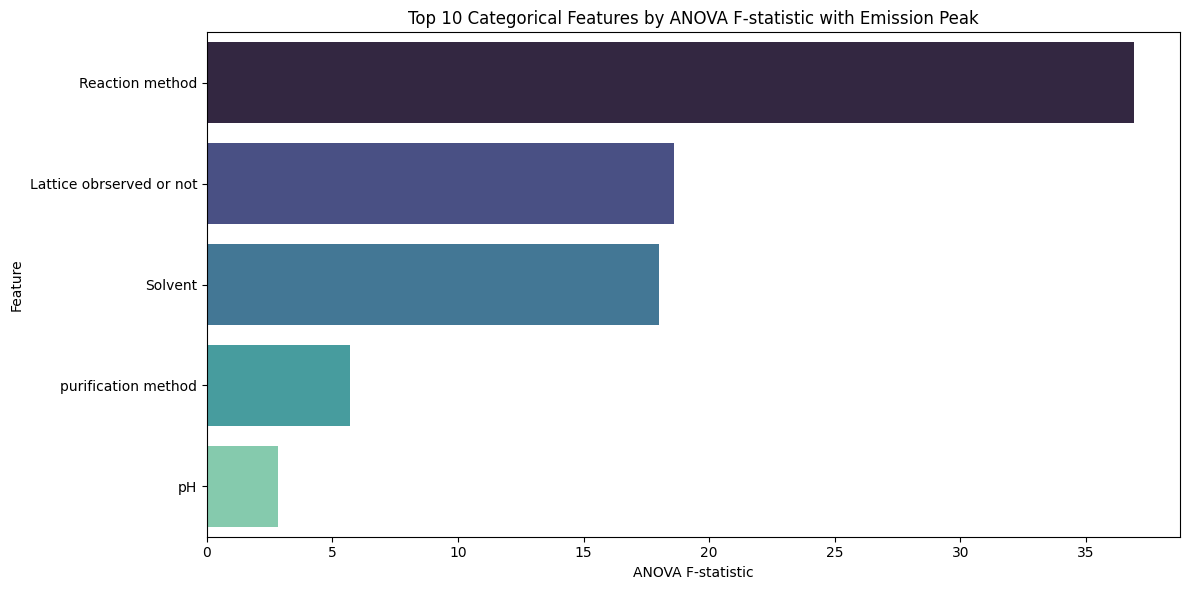


Top Pearson Correlations:


,Feature,Pearson r,p-value,abs_r
0,citric acid,-0.243075,4.178981e-07,0.243075
1,urea,0.242175,4.623515e-07,0.242175
2,ethylenediamine,-0.130666,7.123691e-03,0.130666
11,reaction time (min),-0.079135,1.040964e-01,0.079135
6,boric acid,-0.078771,1.057047e-01,0.078771
7,sodium thiosulfate,-0.050093,3.040216e-01,0.050093
10,Reaction temperatrue( C ),-0.039387,4.190936e-01,0.039387
3,HCl,-0.031840,5.137064e-01,0.031840
5,NaOH,-0.023823,6.251302e-01,0.023823
4,ammonium,-0.022698,6.415642e-01,0.022698



Top ANOVA Categorical Features:


,Feature,F-statistic,p-value
0,Reaction method,36.899104,4.570548e-44
4,Lattice obrserved or not,18.592113,2.035649e-05
1,Solvent,17.987046,1.832273e-36
3,purification method,5.703427,1.904514e-14
2,pH,2.846627,5.916019e-02


In [ ]:
# ====================== Setup ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# Upload your file from Colab
from google.colab import files
uploaded = files.upload()

# Load the uploaded CSV
df = pd.read_csv(next(iter(uploaded)))

# ====================== Define Target ======================
target_col = 'Main Peak (in water)'
df = df.drop(columns=['Example ID', 'DOI', 'Color'], errors='ignore')  # drop unnecessary columns
df = df.dropna(subset=[target_col])  # drop rows with missing target

# ====================== Separate Features ======================
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != target_col]

categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# ====================== Pearson Correlation for Numerical ======================
scaler = StandardScaler()
df_scaled_num = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)

pearson_results = []
for col in df_scaled_num.columns:
    r, p = pearsonr(df_scaled_num[col], df[target_col])
    pearson_results.append((col, r, p))

pearson_df = pd.DataFrame(pearson_results, columns=['Feature', 'Pearson r', 'p-value'])
pearson_df['abs_r'] = np.abs(pearson_df['Pearson r'])
pearson_df.sort_values(by='abs_r', ascending=False, inplace=True)

# ====================== Plot Pearson Heatmap ======================
plt.figure(figsize=(12, 6))
sns.barplot(x='Pearson r', y='Feature', data=pearson_df.head(10), palette='coolwarm')
plt.title('Top 10 Numerical Features by Pearson Correlation with Emission Peak')
plt.xlabel('Pearson Correlation (r)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ====================== ANOVA for Categorical ======================
anova_results = []
for col in categorical_cols:
    try:
        model = ols(f'Q("{target_col}") ~ C(Q("{col}"))', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        F = anova_table['F'].iloc[0]
        p = anova_table['PR(>F)'].iloc[0]
        anova_results.append((col, F, p))
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")

anova_df = pd.DataFrame(anova_results, columns=['Feature', 'F-statistic', 'p-value'])
anova_df.sort_values(by='F-statistic', ascending=False, inplace=True)

# ====================== Plot ANOVA Top Features ======================
plt.figure(figsize=(12, 6))
sns.barplot(x='F-statistic', y='Feature', data=anova_df.head(10), palette='mako')
plt.title('Top 10 Categorical Features by ANOVA F-statistic with Emission Peak')
plt.xlabel('ANOVA F-statistic')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ====================== Optional: Display Data ======================
print("\nTop Pearson Correlations:")
display(pearson_df.head(10))

print("\nTop ANOVA Categorical Features:")
display(anova_df.head(10))


In [ ]:
import pandas as pd
data=pd.read_csv("github.csv")


In [ ]:
data.columns

Index(['Example ID', 'DOI', 'Color', 'citric acid', 'urea', ' ethylenediamine',
       'HCl', 'ammonium', 'NaOH', 'boric acid ', 'sodium thiosulfate', 'KOH',
       'formic acid ', 'Reaction method', 'Solvent', 'pH',
       'Reaction temperatrue( C )', 'reaction time (min)',
       'purification method', 'particle size (TEM)',
       'Lattice obrserved or not', 'absorption', 'Main Peak (in water)'],
      dtype='object')

In [ ]:
data=data[['Color', 'citric acid', 'urea', ' ethylenediamine',
       'HCl', 'ammonium', 'NaOH', 'boric acid ', 'sodium thiosulfate', 'KOH',
       'formic acid ', 'Reaction method', 'Solvent', 'pH',
       'Reaction temperatrue( C )', 'reaction time (min)',
       'purification method']]

In [ ]:
data

,Color,citric acid,urea,ethylenediamine,HCl,ammonium,NaOH,boric acid,sodium thiosulfate,KOH,formic acid,Reaction method,Solvent,pH,Reaction temperatrue( C ),reaction time (min),purification method
0,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,"ethanol, formamide",acidic,423.15,300.000000,centrifuge
1,blue,0.1560,1.0,0.000,0.003,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,240.000000,centrifuge
2,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,ethanol,acidic,473.15,420.000000,"filter, dialysis"
3,blue,0.0825,0.0,0.000,0.000,1,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,7.000000,centrifuge
4,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,360.000000,dialysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,blue,0.2000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,formamide,neutral,473.15,0.833333,filter
419,blue,0.9000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,2.000000,filter
420,blue,0.1000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,neutral,413.15,120.000000,none
421,blue,0.7000,1.0,0.000,0.200,0,0.0,0.0,0.0,0,0,microwave-assisted hydrothermal,water,acidic,413.15,120.000000,none


In [ ]:
data['Color'].value_counts()

,count
Color,
blue,302
green,61
red,25
blue-green,20
multicolor,7
yellow,4
orange,4


In [ ]:
# Replace 'yellow' and 'orange' with 'red' in the 'color' column
data['Color'] = data['Color'].replace({'yellow': 'yor', 'orange': 'yor', 'red': 'yor'})

In [ ]:
data=data[data['Color']!='multicolor']

In [ ]:
data

,Color,citric acid,urea,ethylenediamine,HCl,ammonium,NaOH,boric acid,sodium thiosulfate,KOH,formic acid,Reaction method,Solvent,pH,Reaction temperatrue( C ),reaction time (min),purification method
0,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,"ethanol, formamide",acidic,423.15,300.000000,centrifuge
1,blue,0.1560,1.0,0.000,0.003,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,240.000000,centrifuge
2,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,ethanol,acidic,473.15,420.000000,"filter, dialysis"
3,blue,0.0825,0.0,0.000,0.000,1,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,7.000000,centrifuge
4,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,360.000000,dialysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,blue,0.2000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,formamide,neutral,473.15,0.833333,filter
419,blue,0.9000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,2.000000,filter
420,blue,0.1000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,neutral,413.15,120.000000,none
421,blue,0.7000,1.0,0.000,0.200,0,0.0,0.0,0.0,0,0,microwave-assisted hydrothermal,water,acidic,413.15,120.000000,none


In [ ]:
# Sample list of base methods
base_methods = ['centrifuge', 'dialysis','none', 'filter', 'wash', 'column', 'disperse in water'
                 'sieve', 'precipitate', 'chromatography','heat']

# Assign a scalar embedding for each method
method_encoding = {method: i+1 for i, method in enumerate(base_methods)}  # e.g., 1 to 11

# Positional decay factor
alpha = 0.5  # decay factor for importance

# Load and preprocess
data['purification method'] = data['purification method'].fillna('')
data['purification_list'] = data['purification method'].str.split(',\s*')

# Compute weighted sum encoding
def weighted_sum_encoding(methods):
    return sum((alpha**i) * method_encoding[m] for i, m in enumerate(methods) if m in method_encoding)

data['purification_weighted'] = data['purification_list'].apply(weighted_sum_encoding)



<ipython-input-10-d4d8bba4ad1b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['purification method'] = data['purification method'].fillna('')
<ipython-input-10-d4d8bba4ad1b>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['purification_list'] = data['purification method'].str.split(',\s*')
<ipython-input-10-d4d8bba4ad1b>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [ ]:
data

,Color,citric acid,urea,ethylenediamine,HCl,ammonium,NaOH,boric acid,sodium thiosulfate,KOH,formic acid,Reaction method,Solvent,pH,Reaction temperatrue( C ),reaction time (min),purification method,purification_list,purification_weighted
0,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,"ethanol, formamide",acidic,423.15,300.000000,centrifuge,[centrifuge],1.0
1,blue,0.1560,1.0,0.000,0.003,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,240.000000,centrifuge,[centrifuge],1.0
2,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,solvothermal treatment,ethanol,acidic,473.15,420.000000,"filter, dialysis","[filter, dialysis]",5.0
3,blue,0.0825,0.0,0.000,0.000,1,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,7.000000,centrifuge,[centrifuge],1.0
4,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,acidic,433.15,360.000000,dialysis,[dialysis],2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,blue,0.2000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,formamide,neutral,473.15,0.833333,filter,[filter],4.0
419,blue,0.9000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,microwave,water,neutral,473.15,2.000000,filter,[filter],4.0
420,blue,0.1000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,hydrothermal treatment,water,neutral,413.15,120.000000,none,[none],3.0
421,blue,0.7000,1.0,0.000,0.200,0,0.0,0.0,0.0,0,0,microwave-assisted hydrothermal,water,acidic,413.15,120.000000,none,[none],3.0


In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
# Encode 'Color' column to numeric values
le = LabelEncoder()
data['Color_encoded'] = le.fit_transform(data['Color'])
le = LabelEncoder()
data['purif_initial_encoded'] = le.fit_transform(data['purification method'])

# Compute Pearson correlation
correlation = data[['purification_weighted', 'Color_encoded']].corr(method='pearson').iloc[0, 1]

print(f"Pearson correlation between purification_weighted and Color: {correlation:.4f}")

Pearson correlation between purification_weighted and Color: 0.0587


<ipython-input-14-0f1dd1351ab4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Color_encoded'] = le.fit_transform(data['Color'])
<ipython-input-14-0f1dd1351ab4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['purif_initial_encoded'] = le.fit_transform(data['purification method'])


In [ ]:
correlation = data[['purif_initial_encoded', 'Color_encoded']].corr(method='pearson').iloc[0, 1]
print(correlation)

0.04663602041440747


In [ ]:
solvent_order = {
    'water': 1,
    'formamide': 2,
    'DMF': 3,
    'ethanol': 4,
    'glycerol': 5,
    'none': 6,
    'acetonitrile': 7,
    'pyridine': 8,
    'DMSO': 9,
    'toluene': 10,
    'DEF': 11,
    'hydrogen': 12,
    'oxygen gas': 13
}

In [ ]:
data

,Color,citric acid,urea,ethylenediamine,HCl,ammonium,NaOH,boric acid,sodium thiosulfate,KOH,...,Solvent,pH,Reaction temperatrue( C ),reaction time (min),purification method,purification_list,purification_weighted,Color_encoded,purif_initial_encoded,solvent_encoded
0,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,...,"ethanol, formamide",acidic,423.15,300.000000,centrifuge,[centrifuge],1.0,0,0,5
1,blue,0.1560,1.0,0.000,0.003,0,0.0,0.0,0.0,0,...,water,acidic,433.15,240.000000,centrifuge,[centrifuge],1.0,0,0,13
2,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,...,ethanol,acidic,473.15,420.000000,"filter, dialysis","[filter, dialysis]",5.0,0,15,4
3,blue,0.0825,0.0,0.000,0.000,1,0.0,0.0,0.0,0,...,water,neutral,473.15,7.000000,centrifuge,[centrifuge],1.0,0,0,13
4,blue,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,...,water,acidic,433.15,360.000000,dialysis,[dialysis],2.0,0,8,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,blue,0.2000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,...,formamide,neutral,473.15,0.833333,filter,[filter],4.0,0,10,6
419,blue,0.9000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,...,water,neutral,473.15,2.000000,filter,[filter],4.0,0,10,13
420,blue,0.1000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,...,water,neutral,413.15,120.000000,none,[none],3.0,0,18,13
421,blue,0.7000,1.0,0.000,0.200,0,0.0,0.0,0.0,0,...,water,acidic,413.15,120.000000,none,[none],3.0,0,18,13


In [ ]:
data = data.copy()
le = LabelEncoder()
data['solvent_encoded'] = le.fit_transform(data['Solvent'])
correlation = data[['solvent_encoded', 'Color_encoded']].corr(method='pearson').iloc[0, 1]
print(correlation)

-0.5392000052447449


In [ ]:
le = LabelEncoder()
data['Reaction_method_encoded'] = le.fit_transform(data['Reaction method'])
correlation = data[['Reaction_method_encoded', 'Color_encoded']].corr(method='pearson').iloc[0, 1]
print(correlation)

0.5569662645857706


In [ ]:
data['pH'].value_counts()
ph_encoding = {
    'acidic': 0,
    'neutral': 1,
    'basic': 2
}

data['pH_encoded'] = data['pH'].map(ph_encoding)

In [ ]:
correlation = data[['pH_encoded', 'Color_encoded']].corr(method='pearson').iloc[0, 1]
print(correlation)

0.16397423423496177


In [ ]:
data

,citric acid,urea,ethylenediamine,HCl,ammonium,NaOH,boric acid,sodium thiosulfate,KOH,formic acid,Reaction temperatrue( C ),reaction time (min),purification_weighted,Color_encoded,solvent_encoded,Reaction_method_encoded,pH_encoded
0,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,423.15,300.000000,1.0,0,5,8,0
1,0.1560,1.0,0.000,0.003,0,0.0,0.0,0.0,0,0,433.15,240.000000,1.0,0,13,2,0
2,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,473.15,420.000000,5.0,0,4,8,0
3,0.0825,0.0,0.000,0.000,1,0.0,0.0,0.0,0,0,473.15,7.000000,1.0,0,13,3,1
4,1.0000,0.0,0.000,0.000,0,0.0,0.0,0.0,0,0,433.15,360.000000,2.0,0,13,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,0.2000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,473.15,0.833333,4.0,0,6,3,1
419,0.9000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,473.15,2.000000,4.0,0,13,3,1
420,0.1000,0.0,1.000,0.000,0,0.0,0.0,0.0,0,0,413.15,120.000000,3.0,0,13,2,1
421,0.7000,1.0,0.000,0.200,0,0.0,0.0,0.0,0,0,413.15,120.000000,3.0,0,13,4,0


In [ ]:
data.columns

In [ ]:
data=data[['citric acid', 'urea', ' ethylenediamine', 'HCl', 'ammonium',
       'NaOH', 'boric acid ', 'sodium thiosulfate', 'KOH', 'formic acid ','Reaction temperatrue( C )',
       'reaction time (min)','purification_weighted', 'Color_encoded','solvent_encoded', 'Reaction_method_encoded','pH_encoded']]

In [ ]:
data['solvent_encoded'].value_counts()

,count
solvent_encoded,
13,330
1,24
10,21
6,20
4,5
7,4
5,2
14,2
8,2


In [ ]:
data=data[data['Solvent']!='DMSO']
data=data[data['Solvent']!='glycerol, DMF']
data=data[data['Solvent']!='DEF']

KeyError: 'Solvent'

In [ ]:
# data_yor['Solvent'].value_counts()

In [ ]:
# data_yor=data[data['Color']=='yor']

In [ ]:
data

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
# Separate features and target
X = data.drop(columns=['Color_encoded'])      # all other features
y = data['Color_encoded']                     # target column

# Encode 'Color' to numeric for SMOTE
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Apply SMOTE to oversample minority classes
sm = SMOTE(sampling_strategy='not majority', random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y_encoded)

# Convert encoded labels back to original
y_resampled_labels = le.inverse_transform(y_resampled)

# Combine back into a DataFrame
data_resampled = pd.DataFrame(X_resampled, columns=X.columns)
data_resampled['Color_encoded'] = y_resampled_labels

In [ ]:
data_resampled

In [ ]:
data_resampled['Color_encoded'].value_counts()

,count
Color_encoded,
0,302
2,302
3,302
1,302


In [ ]:

# Generate realistic synthetic data that mimics the structure from the user's screenshot
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score

# Define the column structure as seen
columns = [
    'citric acid', 'urea', 'ethylenediamine', 'HCl', 'ammonium', 'NaOH',
    'boric acid', 'sodium thiosulfate', 'KOH', 'formic acid',
    'Reaction temperature(℃)', 'reaction time (min)', 'purification_weighted',
    'solvent_encoded', 'Reaction_method_encoded', 'pH_encoded', 'Color_encoded'
]


# Features and target
X = data_resampled.drop('Color_encoded', axis=1)
y = data_resampled['Color_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "SVM": SVC(probability=True),
    "ANN": MLPClassifier(max_iter=1000)
}

# Evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    macro_auc = roc_auc_score(y_test, y_prob, multi_class='ovo', average='macro')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    row = {
        "Model": name,
        "Class 0 Acc": report['0']['recall'],
        "Class 1 Acc": report['1']['recall'],
        "Class 2 Acc": report['2']['recall'],
        "Class 3 Acc": report['3']['recall'],
        "Macro AUC": macro_auc,
        "Macro F1": macro_f1,
        "Precision": precision,
        "Recall": recall
    }
    results.append(row)

results_df = pd.DataFrame(results)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:50:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
results_df

,Model,Class 0 Acc,Class 1 Acc,Class 2 Acc,Class 3 Acc,Macro AUC,Macro F1,Precision,Recall
0,Logistic Regression,0.686567,0.766667,0.447761,0.937500,0.883528,0.691594,0.706911,0.709624
1,Decision Tree,0.895522,0.966667,0.835821,0.895833,0.938152,0.897040,0.895916,0.898461
2,Random Forest,0.955224,0.983333,0.835821,1.000000,0.985035,0.937640,0.936792,0.943595
3,XGBoost,0.910448,0.950000,0.865672,0.958333,0.982295,0.917421,0.915666,0.921113
4,SVM,0.865672,0.933333,0.388060,1.000000,0.926401,0.766989,0.821467,0.796766
5,ANN,0.865672,0.950000,0.746269,1.000000,0.979941,0.882613,0.886147,0.890485


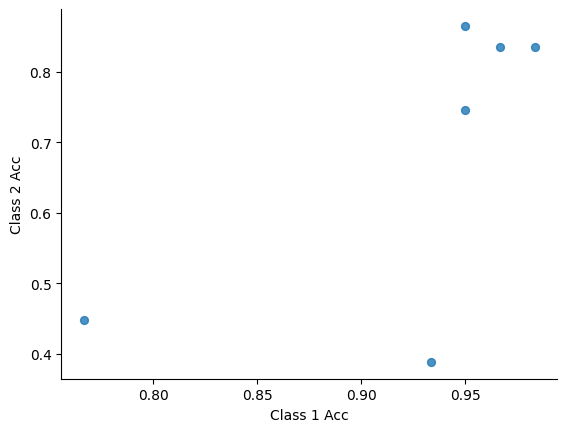

In [ ]:
# @title Class 1 Acc vs Class 2 Acc

from matplotlib import pyplot as plt
results_df.plot(kind='scatter', x='Class 1 Acc', y='Class 2 Acc', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
results_df

,Model,Class 0 Acc,Class 1 Acc,Class 2 Acc,Class 3 Acc,Macro AUC,Macro F1,Precision,Recall
0,Logistic Regression,0.686567,0.766667,0.447761,0.937500,0.883528,0.691594,0.706911,0.709624
1,Decision Tree,0.895522,0.966667,0.835821,0.895833,0.938152,0.897040,0.895916,0.898461
2,Random Forest,0.955224,0.983333,0.835821,1.000000,0.985035,0.937640,0.936792,0.943595
3,XGBoost,0.910448,0.950000,0.865672,0.958333,0.982295,0.917421,0.915666,0.921113
4,SVM,0.865672,0.933333,0.388060,1.000000,0.926401,0.766989,0.821467,0.796766
5,ANN,0.865672,0.950000,0.746269,1.000000,0.979941,0.882613,0.886147,0.890485


In [ ]:
import joblib

# Define model names and file paths
model_paths = {
    "Logistic Regression": "logistic_regression_model.pkl",
    "Decision Tree": "decision_tree_model.pkl",
    "Random Forest": "random_forest_model.pkl",
    "XGBoost": "xgboost_model.pkl",
    "SVM": "svm_model.pkl",
    "ANN": "ann_model.pkl"
}

# Fit and save each model
for name, model in models.items():
    model.fit(X_train, y_train)
    joblib.dump(model, model_paths[name])
    print(f"{name} saved to {model_paths[name]}")

Logistic Regression saved to logistic_regression_model.pkl
Decision Tree saved to decision_tree_model.pkl
Random Forest saved to random_forest_model.pkl


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:52:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost saved to xgboost_model.pkl
SVM saved to svm_model.pkl
ANN saved to ann_model.pkl


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Assuming your full dataset X (features only) is available
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
scaler.fit(X)  # X = your features without Color_encoded
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [ ]:
import numpy as np
import joblib

# === STEP 1: Manually enter your feature values ===
# Follow this exact order:
# [citric acid, urea, ethylenediamine, HCl, ammonium, NaOH,
#  boric acid, sodium thiosulfate, KOH, formic acid,
#  Reaction temperature(℃), reaction time (min), purification_weighted,
#  solvent_encoded, Reaction_method_encoded, pH_encoded]

input_features = [
    0.15, 1, 0.0, 0.0, 0, 0,
    0.0, 0.0, 0.0, 0.0,
    180, 360.0, 1.0,
    4, 1, 0
]

# === STEP 2: Reshape your input for the models ===
input_array = np.array(input_features).reshape(1, -1)

# === STEP 3: Define saved model paths ===
model_paths = {
    "Logistic Regression": "logistic_regression_model.pkl",
    "Decision Tree": "decision_tree_model.pkl",
    "Random Forest": "random_forest_model.pkl",
    "XGBoost": "xgboost_model.pkl",
    "SVM": "svm_model.pkl",
    "ANN": "ann_model.pkl"
}

# === STEP 4: Predict from each model ===
print("\nPredictions from all models:")
for name, path in model_paths.items():
    model = joblib.load(path)
    pred = model.predict(input_array)[0]
    print(f"{name}: Color_encoded = {pred}")



Predictions from all models:
Logistic Regression: Color_encoded = 0
Decision Tree: Color_encoded = 1
Random Forest: Color_encoded = 0
XGBoost: Color_encoded = 0
SVM: Color_encoded = 0
ANN: Color_encoded = 0


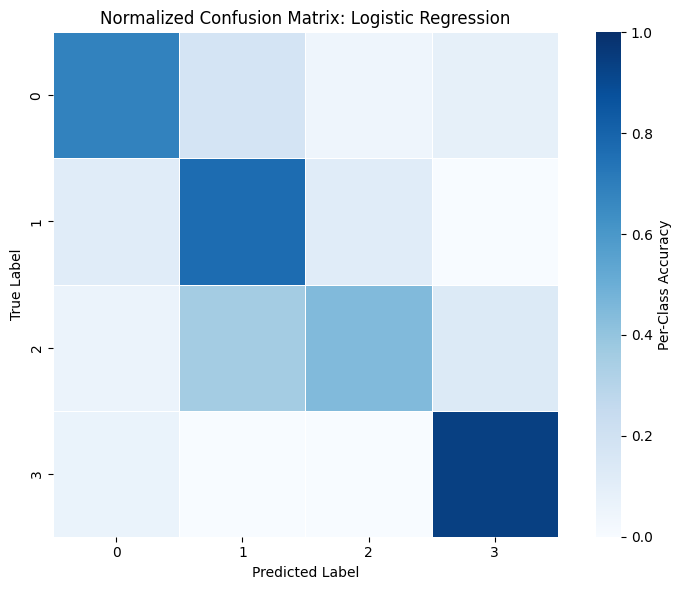

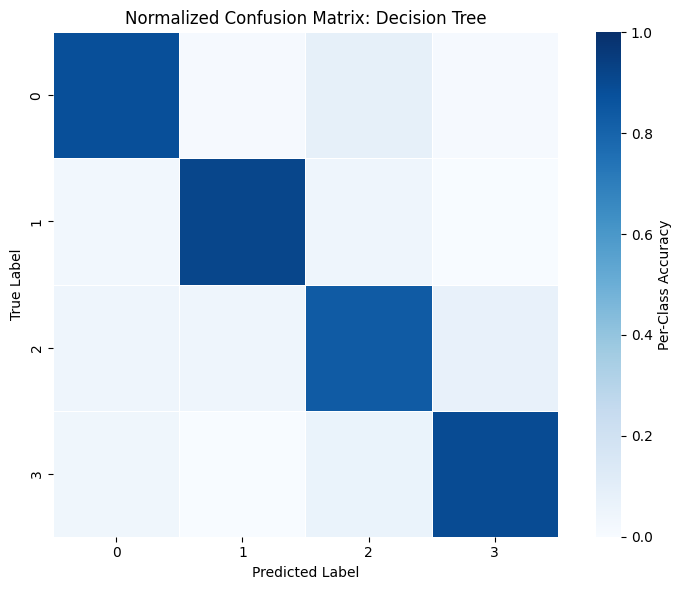

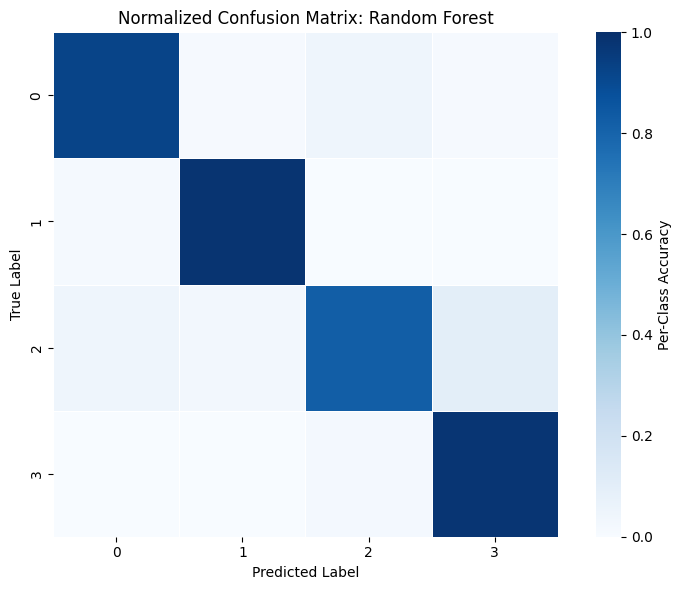

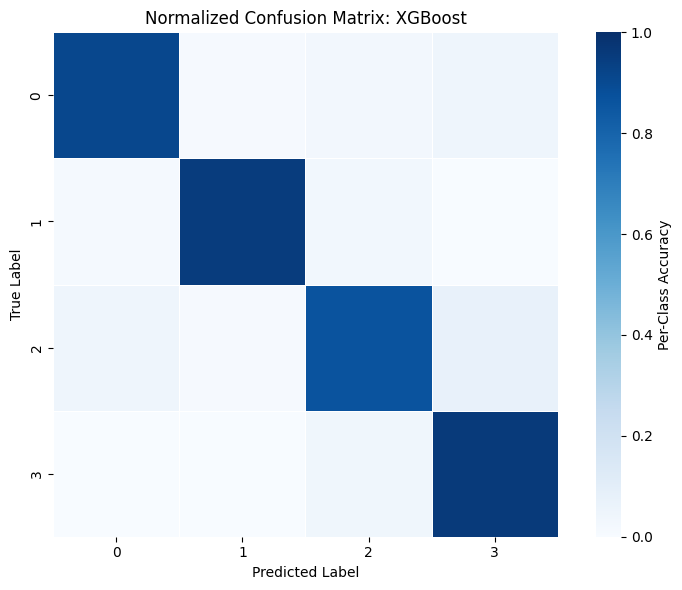

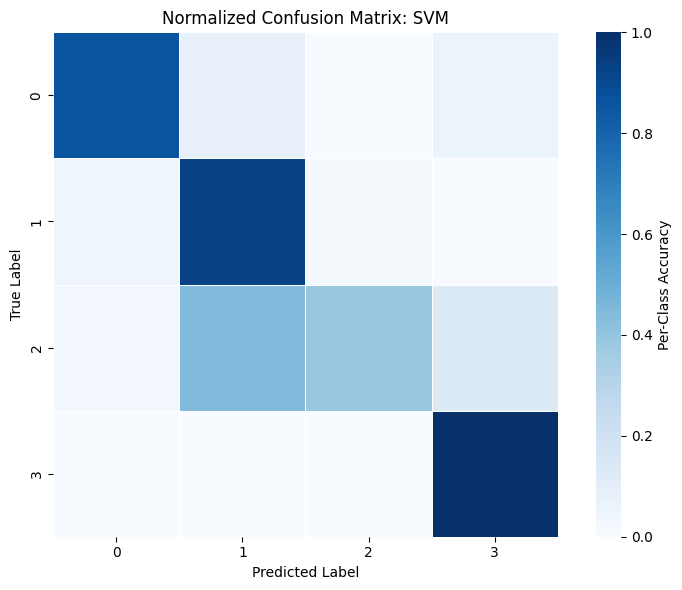

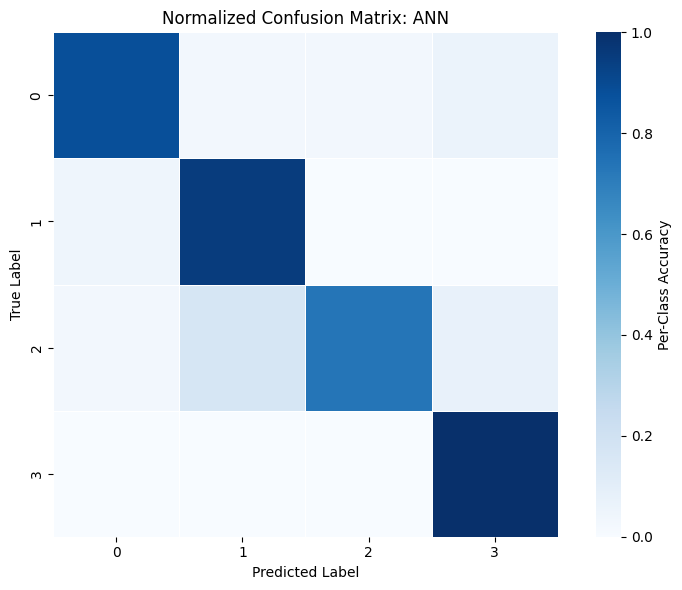

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure 'models', 'X_test', 'y_test', and 'le' (LabelEncoder) are already defined

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Row-wise normalization: each row sums to 1 (i.e., per-class accuracy view)
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=False,            # No numbers
        cmap='Blues',           # Blue color map
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Per-Class Accuracy'},
        vmin=0, vmax=1          # Fix scale across all models
    )
    plt.title(f"Normalized Confusion Matrix: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Create a directory to save ROC plots
os.makedirs("roc_curves", exist_ok=True)

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

for name, model in models.items():
    if hasattr(model, "predict_proba"):  # Ensure predict_proba is supported
        y_score = model.predict_proba(X_test)

        # Compute ROC for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute micro-average ROC curve and AUC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Plot ROC curve (all classes in one figure)
        plt.figure(figsize=(8, 6))
        for i in range(n_classes):
            plt.plot(
                fpr[i], tpr[i],
                lw=2,
                label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
            )

        # Reference line
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
        plt.title(f'ROC Curve: {name}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()

        # Save the figure
        file_path = f"roc_curves/ROC_Curve_{name.replace(' ', '_')}.png"
        plt.savefig(file_path, dpi=300)
        plt.close()
        print(f"✅ Saved: {file_path}")
    else:
        print(f"⚠️ Skipped {name}: predict_proba not available")


✅ Saved: roc_curves/ROC_Curve_Logistic_Regression.png
✅ Saved: roc_curves/ROC_Curve_Decision_Tree.png
✅ Saved: roc_curves/ROC_Curve_Random_Forest.png
✅ Saved: roc_curves/ROC_Curve_XGBoost.png
✅ Saved: roc_curves/ROC_Curve_SVM.png
✅ Saved: roc_curves/ROC_Curve_ANN.png


<ipython-input-46-ffe54d529cd3>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


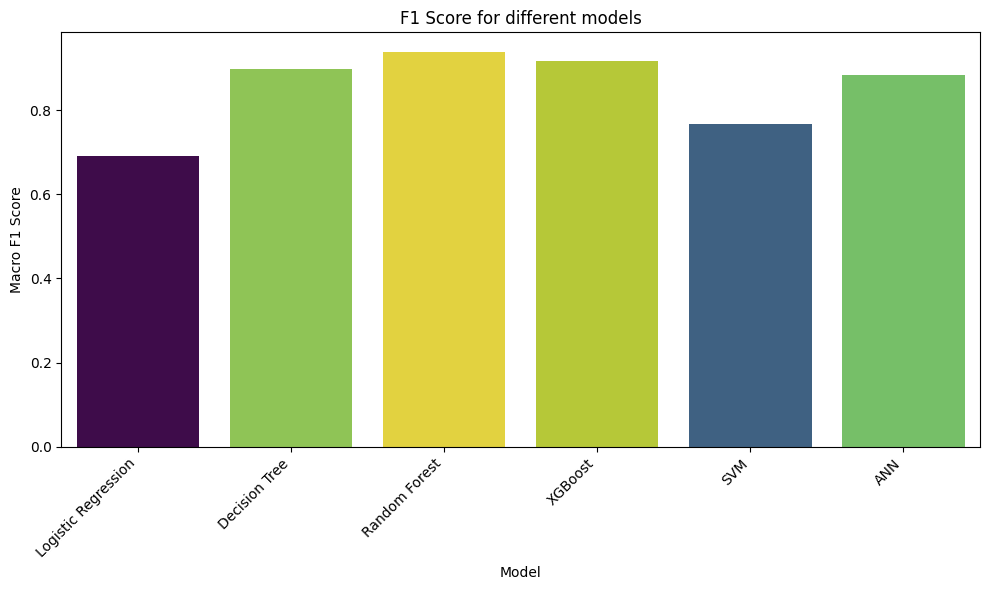

In [ ]:
# prompt: make an f1 score plot for different models and the bars should have colors with intensity greater for model with ghreater f1 score

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'results_df' is your DataFrame with model results
plt.figure(figsize=(10, 6))

# Normalize F1 scores to 0-1 for color intensity
f1_min = results_df['Macro F1'].min()
f1_max = results_df['Macro F1'].max()
normalized_f1 = (results_df['Macro F1'] - f1_min) / (f1_max - f1_min)


# Create the bar plot with color intensity based on normalized f1 score
sns.barplot(
    x='Model',
    y='Macro F1',
    data=results_df,
    palette=[plt.cm.viridis(x) for x in normalized_f1] # Use viridis colormap for intensity
)


plt.title('F1 Score for different models')
plt.xlabel('Model')
plt.ylabel('Macro F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# prompt: i want to see which color(eg yor) is which class(eg 1)

# Assuming 'data_resampled' DataFrame exists as in your provided code

# Display the mapping of Color_encoded to actual color values
color_mapping = dict(zip(data_resampled['Color_encoded'].unique(), le.inverse_transform(data_resampled['Color_encoded'].unique())))
print("Color Encoding Mapping:")
for encoded_value, color in color_mapping.items():
    print(f"{encoded_value} : {color}")


Color Encoding Mapping:
0 : 0
2 : 2
3 : 3
1 : 1
